<a href="https://colab.research.google.com/github/sayu0303/CONTROLE-2025/blob/main/P8_do_zero_CONTROLE_080226.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CONTROLE DE PROCESSOS
---------------------------------

###REFAZENDO E REORGANIZANDO A PRÁTICA 8 EXECUTADA EM SALA DE AULA


##**Exemplo resolvido PARA MALHA FECHADA (tentando executar o código em um único bloco)**

---


In [1]:
#Instalação da biblioteca control

!pip install control -qq control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.7 MB/s eta 0:00:00


### **Método de Sundaresan e Krishnaswamy (1° Ordem) + IMC**

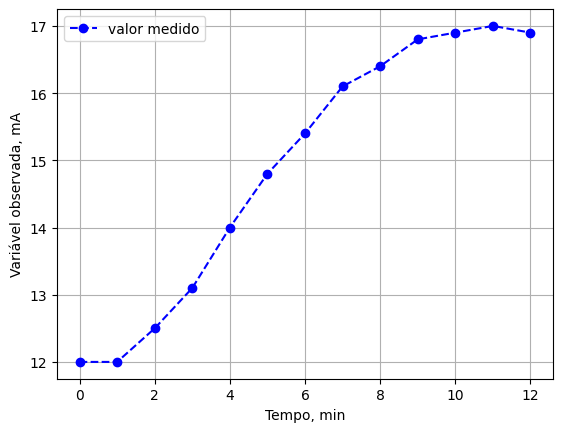

In [2]:
#Importação das bibliotecas utilizadas

import numpy as np                   #Biblioteca de operações matemáticas
import matplotlib.pyplot as plt      #Biblioteca para plotagem de gráficos
import control as ct                 #Biblioteca para implementação de controle
from sklearn.metrics import r2_score #Importar a função do R²
#Definição dos dados de tempo e temperatura, propostas no problema

tempo = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
T_2m = np.array([12, 12, 12.5, 13.1, 14, 14.8, 15.4, 16.1, 16.4, 16.8, 16.9, 17, 16.9])

plt.plot(tempo,T_2m, '--ob', label = 'valor medido')
plt.xlabel('Tempo, min')
plt.ylabel('Variável observada, mA')
plt.legend()
plt.grid()

In [3]:
#APLICAÇÃO DO MÉTODO DE SUNDARESAN E KRISHNASWAY

'''
Esse método é aplicado quando trata-se de um sistema com muitos ruídos. Com isso,
o método já "pré-define" os chutes a serem feitos, no caso do exercício proposto
é em relação ao tempo, sendo t1 = 35,3% e t2 = 85,3%.

'''

#Chutes iniciais de temperatura

T1_SK = 3.
T2_SK = 7

'''
Com a determinação dos tempos em relação ao chute "pré-definido" menos o tempo morto do exercício do método,
é possível estimar os parâmetros do método de 1ª Ordem, também definidas pelo
método.

'''

#Definição de theta e tau

tau_SK = 0.67*(T2_SK - T1_SK)         #Definição de theta de acordo com o método
theta_SK = (1.3*T1_SK) - (0.29*T2_SK) #Definição de tau de acordo com o método

print(f'Determinação dos parâmetros para um sistema de 1ª ordem: Theta = {theta_SK} e Tau = {tau_SK}')

#Definição do meu parâmetro K


'''
Aqui, deve ser seguido o que foi proposto pelo método para o cáculo do parâmetro K,
em um sistema de 1ª ordem. De acordo com a equação expressa a seguir.

'''

delta_PSK = 20 - 18        #Definição do meu delta y, seguindo a proposta do método, subtraindo a variação da pressão proposta no exercício
delta_TSK = 17 - T_2m[0]   #Definição do meu delta u, considerando o maior valor de T com o menor

K_SK = delta_TSK/delta_PSK

print(f'O ganho do processo (K) calculado é: {K_SK}')

Determinação dos parâmetros para um sistema de 1ª ordem: Theta = 1.8700000000000006 e Tau = 2.68
O ganho do processo (K) calculado é: 2.5


Text(0.5, 1.0, 'Qualidade do modelo: $R^2$ = 0.9612')

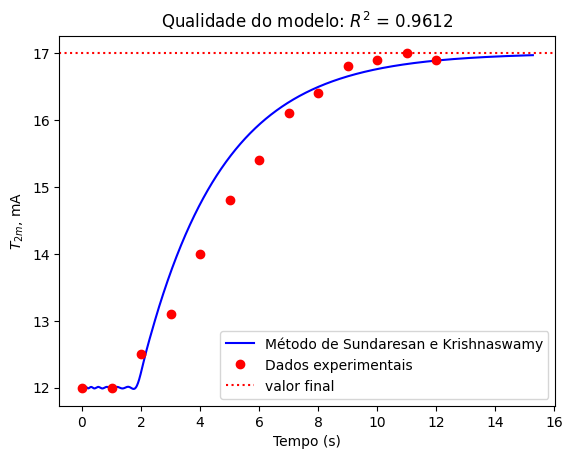

In [4]:
#Definição do modelo

Gdt_SK = ct.tf(*ct.pade(theta_SK, 15)) #Aproximação de padé para o atraso de tempo theta, convertendo o atraso puro em uma funçãode transferência racional
G_SK = ct.tf(K_SK,[tau_SK,1])*Gdt_SK #Definição do modelo de 1ª Ordem

#Simulação do modelo nos dados gerados

tsim_SK, ysim_SK = ct.step_response(G_SK,T=tempo) #Cálculo da resposta ao degrau do sistema, utilizando o vetor de tempo definido
Tsim_SK = delta_PSK * ysim_SK + T_2m[0]              #Cálculo da temperatura simulada

# Tempo final da simulação definido como θ + 5τ para garantir acomodação da resposta

tval_SK, yval_SK = ct.step_response(G_SK,T=5*tau_SK+theta_SK)

#Plotagem dos dados gerados pelo modelo

plt.plot(tval_SK,delta_PSK * yval_SK + T_2m[0], '-b', label = 'Método de Sundaresan e Krishnaswamy')
plt.plot(tempo,T_2m, 'or', label = 'Dados experimentais')
plt.axhline(y=17, linestyle = ':', color = 'red', label = 'valor final')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel(r'$T_{2m}$, mA')
plt.title(r'Qualidade do modelo: $R^2$ = %1.4f' %r2_score(T_2m, Tsim_SK))

IMC: Kc =  0.2866310160427807; tauI = 2.68
ITAE: Kc = 0.4883729478657678; tauI = 3.113117623337395 


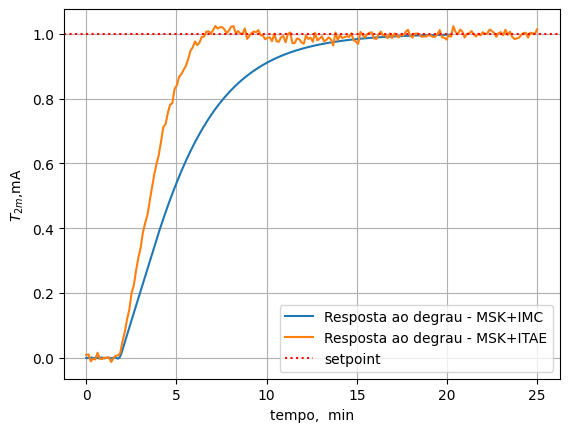

In [5]:
#AJUSTEMDO PARÂMETRO UTILIZANDO IMC

#Redefinição do theta, segundo o exercício propos

tauc_SK = theta_SK

#Definição do K do controlador

Kc_SK = tau_SK / (K_SK*(tauc_SK + theta_SK))


#Redefinição do tau, de acordo com o exercicio

tauI_SK = tau_SK

print(f'IMC: Kc =  {Kc_SK}; tauI = {tauI_SK}')

#CRIAR A GC USANDO controlador pi
s = ct.tf('s')
Gc_SK = Kc_SK*(1+1/(tauI_SK*s))

#Teste servo em malha fechada

Gv = 0.9
G_IP = 0.75

#MALHA FECHADA
G_servoSK = ct.minreal((Gc_SK*G_IP*Gv*G_SK)/(1+Gc_SK*G_IP*Gv*G_SK), verbose=False)


#Simulação da malha fechada

tsim, ysim =  ct.step_response(G_servoSK)

#ITAE

A = 0.859
B = -0.977
C = 0.674
D = -0.680

Kc_ITAE = (A/K_SK)*((theta_SK/tau_SK)**B)

tauI_ITAE = tau_SK/(C*(theta_SK/tau_SK)**D)

print(f'ITAE: Kc = {Kc_ITAE}; tauI = {tauI_ITAE} ')

#CRIAR A GC USANDO controlador pi

Gc_ITAE = Kc_ITAE*(1+1/(tauI_ITAE*s))

#MALHA FECHADA
G_servoITAE = ct.minreal((Gc_ITAE*G_IP*Gv*G_SK)/(1+Gc_ITAE*G_IP*Gv*G_SK), verbose=False)


#Simulação da malha fechada

tsim2, ysim2 =  ct.step_response(G_servoITAE, T=np.linspace(0,25,200))


#Visualização
N = len(ysim2)
plt.plot(tsim,ysim, label = 'Resposta ao degrau - MSK+IMC')
plt.plot(tsim2,ysim2 + 0.01*np.random.randn(N), label = 'Resposta ao degrau - MSK+ITAE')
plt.axhline(y=1, linestyle = ':', color = 'red', label = 'setpoint')
plt.legend()
plt.grid()
plt.xlabel('tempo,  min')
plt.ylabel(r'$T_{2m}$,mA');